In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier


class Dataset:
    def __init__(self):
        # Load dataset
        data = load_breast_cancer()
        
        self.data = data.data
        self.target = data.target
        self.feature_names = data.feature_names
        self.target_names = data.target_names
        
        # Clean data
        self.__load_and_clean_data()

    def __load_and_clean_data(self):
        df = pd.DataFrame(self.data, columns=self.feature_names)
        df['target'] = self.target

        # Remove duplicates
        df = df.drop_duplicates()

        # Remove missing values
        df = df.dropna()

        # Update attributes
        self.data = df[self.feature_names].values
        self.target = df['target'].values

    def split_data(self, test_size=0.2, stratify=True, random_state=42):
        stratify_target = self.target if stratify else None

        return train_test_split(
            self.data,
            self.target,
            test_size=test_size,
            stratify=stratify_target,
            random_state=random_state
        )

    def scale_data(self, X_train, X_test, scale_type='standard'):
        scalers = {
            'standard': StandardScaler(),
            'minmax': MinMaxScaler()
        }

        if scale_type not in scalers:
            raise ValueError("Invalid scale_type. Use 'standard' or 'minmax'.")

        scaler = scalers[scale_type]

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        return X_train_scaled, X_test_scaled

    def __generic_plot(self, plot_func, *args, **kwargs):
        title = kwargs.pop('title', '')
        xlabel = kwargs.pop('xlabel', '')
        ylabel = kwargs.pop('ylabel', '')

        plt.figure(figsize=(8, 6))
        plot_func(*args, **kwargs)

        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.show()

    def visualize_feature_distribution(self, feature_index, scaled_data=None, title_suffix=""):
        if feature_index < 0 or feature_index >= len(self.feature_names):
            raise ValueError("Invalid feature index")

        feature_name = self.feature_names[feature_index]
        original_data = self.data[:, feature_index]

        self.__generic_plot(
            sns.boxplot,
            x=original_data,
            title=f"{feature_name} (Original) {title_suffix}"
        )

        if scaled_data is not None:
            scaled_feature = scaled_data[:, feature_index]

            self.__generic_plot(
                sns.boxplot,
                x=scaled_feature,
                title=f"{feature_name} (Scaled) {title_suffix}"
            )

    def plot_class_distribution(self):
        df = pd.DataFrame({'target': self.target})

        self.__generic_plot(
            sns.countplot,
            x='target',
            data=df,
            title="Class Distribution"
        )

    def plot_correlation_matrix(self):
        df = pd.DataFrame(self.data, columns=self.feature_names)
        corr = df.corr()

        plt.figure(figsize=(12, 10))
        sns.heatmap(corr, cmap='coolwarm')
        plt.title("Correlation Matrix")
        plt.show()

    def feature_importance(self):
        model = RandomForestClassifier(random_state=42)
        model.fit(self.data, self.target)

        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]

        plt.figure(figsize=(12, 6))
        plt.bar(range(len(importances)), importances[indices])
        plt.xticks(range(len(importances)), self.feature_names[indices], rotation=90)
        plt.title("Feature Importance")
        plt.show()

    def plot_feature_distributions(self):
        df = pd.DataFrame(self.data, columns=self.feature_names)
        df.hist(figsize=(15, 12))
        plt.suptitle("Feature Distributions")
        plt.show()

    def plot_box_plots(self, scaled_data=None, target=None):
        data = scaled_data if scaled_data is not None else self.data
        target = target if target is not None else self.target

        if len(data) != len(target):
            raise ValueError("Data and target length mismatch")

        df = pd.DataFrame(data, columns=self.feature_names)
        df['target'] = target

        melted = df.melt(id_vars='target')

        plt.figure(figsize=(15, 8))
        sns.boxplot(x='variable', y='value', hue='target', data=melted)
        plt.xticks(rotation=90)
        plt.title("Boxplots by Class")
        plt.show()

    def plot_pair_plot(self, features):
        df = pd.DataFrame(self.data, columns=self.feature_names)
        df['target'] = self.target

        sns.pairplot(df[features + ['target']], hue='target')
        plt.show()

    def plot_all_features_before_after_scaling(self, X_train, X_train_scaled, scale_type):
        plt.figure(figsize=(12, 6))
        plt.boxplot(X_train)
        plt.title("Before Scaling")
        plt.xticks(range(1, len(self.feature_names)+1), self.feature_names, rotation=90)
        plt.show()

        plt.figure(figsize=(12, 6))
        plt.boxplot(X_train_scaled)
        plt.title(f"After {scale_type} Scaling")
        plt.xticks(range(1, len(self.feature_names)+1), self.feature_names, rotation=90)
        plt.show()

    def plot_feature_before_after_scaling(self, X_train, X_train_scaled, feature_name):
        if feature_name not in self.feature_names:
            raise ValueError("Invalid feature name")

        idx = list(self.feature_names).index(feature_name)

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.hist(X_train[:, idx], bins=30)
        plt.title(f"{feature_name} (Original)")

        plt.subplot(1, 2, 2)
        plt.hist(X_train_scaled[:, idx], bins=30)
        plt.title(f"{feature_name} (Scaled)")

        plt.show()

In [7]:
import pandas as pd

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"
data_hf = pd.read_csv(url)

# Basic check
print(data_hf.shape)
data_hf.head()

(299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [9]:
dataset = Dataset(data_hf)

# Task 1 output
print("=== STATISTICS ===")
print(dataset.calculate_statistics())

# Task 3 output
print("\n=== SUMMARY (ALL FEATURES) ===")
print(dataset.summarize_features())

# Task 4 output
print("\n=== SUMMARY (SELECTED FEATURES) ===")
print(dataset.summarize_features(feature_names=['age', 'sex', 'serum_creatinine']))

=== STATISTICS ===
                                   mean    median       std_dev
age                           60.833893      60.0     11.894809
anaemia                        0.431438       0.0      0.496107
creatinine_phosphokinase     581.839465     250.0    970.287881
diabetes                       0.418060       0.0      0.494067
ejection_fraction             38.083612      38.0     11.834841
high_blood_pressure            0.351171       0.0      0.478136
platelets                 263358.029264  262000.0  97804.236869
serum_creatinine               1.393880       1.1      1.034510
serum_sodium                 136.625418     137.0      4.412477
sex                            0.648829       1.0      0.478136
smoking                        0.321070       0.0      0.467670
time                         130.260870     115.0     77.614208
DEATH_EVENT                    0.321070       0.0      0.467670

=== SUMMARY (ALL FEATURES) ===
                          unique_values  most_common 

In [10]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

class DataScaler:
    def __init__(self, dataframe):
        self.df = dataframe.select_dtypes(include=['int64', 'float64'])

    def standard_scale(self):
        return StandardScaler().fit_transform(self.df)

    def minmax_scale(self):
        return MinMaxScaler().fit_transform(self.df)

    def robust_scale(self):
        return RobustScaler().fit_transform(self.df)

In [11]:
scaler = DataScaler(data_hf)

standard_scaled = scaler.standard_scale()
minmax_scaled = scaler.minmax_scale()
robust_scaled = scaler.robust_scale()

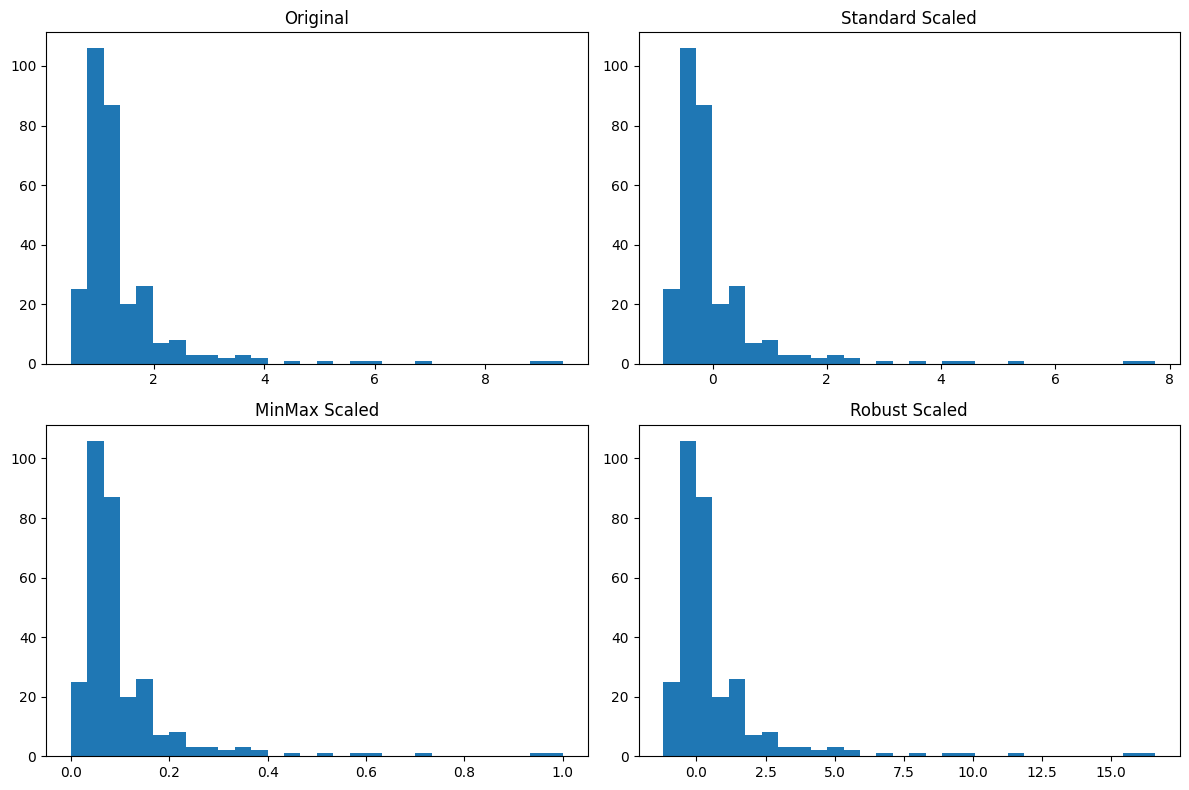

In [12]:
import matplotlib.pyplot as plt

feature = 'serum_creatinine'
col_index = data_hf.columns.get_loc(feature)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.hist(data_hf[feature], bins=30)
plt.title("Original")

plt.subplot(2,2,2)
plt.hist(standard_scaled[:, col_index], bins=30)
plt.title("Standard Scaled")

plt.subplot(2,2,3)
plt.hist(minmax_scaled[:, col_index], bins=30)
plt.title("MinMax Scaled")

plt.subplot(2,2,4)
plt.hist(robust_scaled[:, col_index], bins=30)
plt.title("Robust Scaled")

plt.tight_layout()
plt.show()

In [13]:
data_hf['risk'] = data_hf.apply(
    lambda row: 'High' if row['age'] > 50 and row['serum_creatinine'] > 1.2 else 'Low',
    axis=1
)

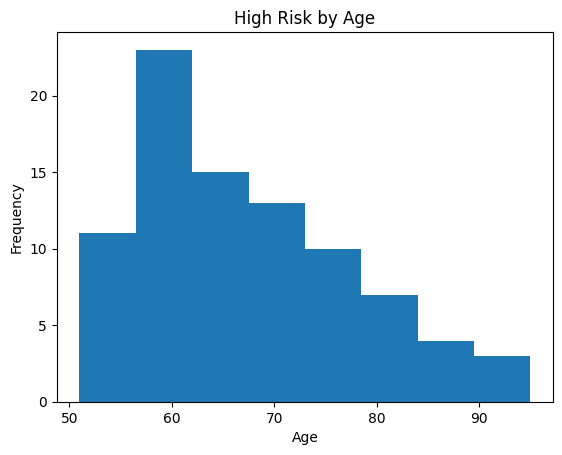

In [14]:
high_risk = data_hf[data_hf['risk'] == 'High']

plt.hist(high_risk['age'], bins='auto')
plt.title('High Risk by Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

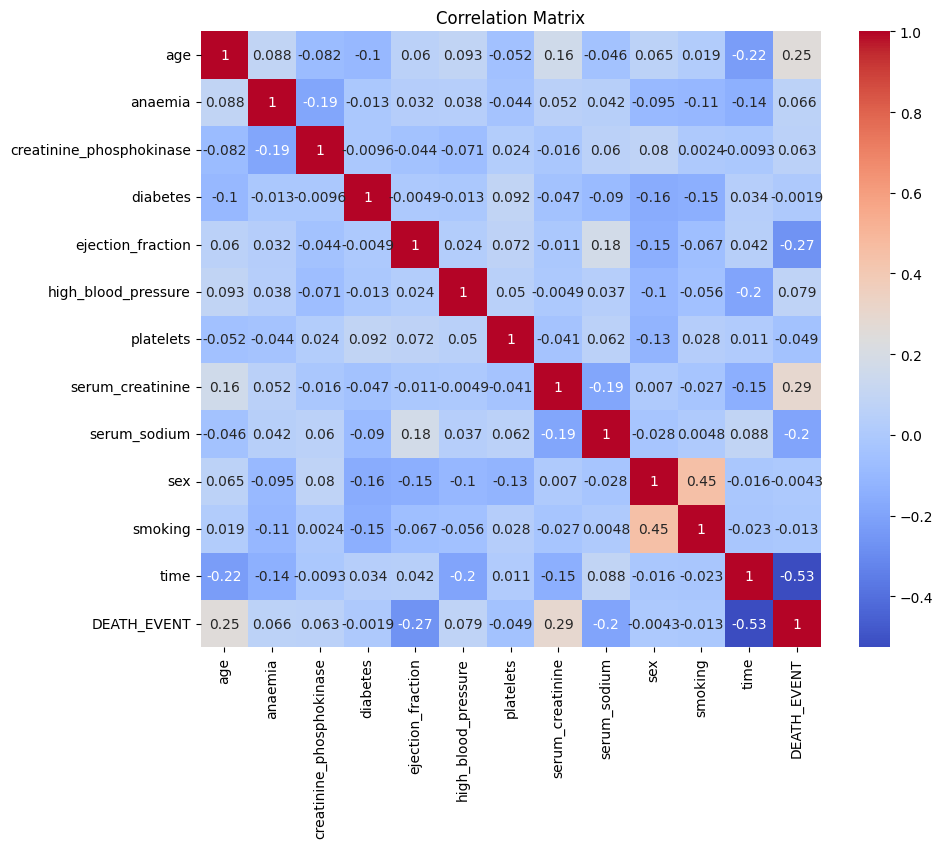

In [15]:
import seaborn as sns

corr = data_hf.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

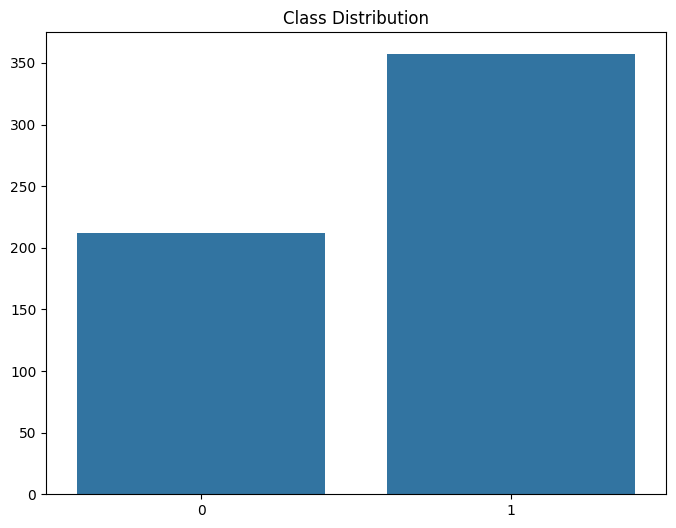

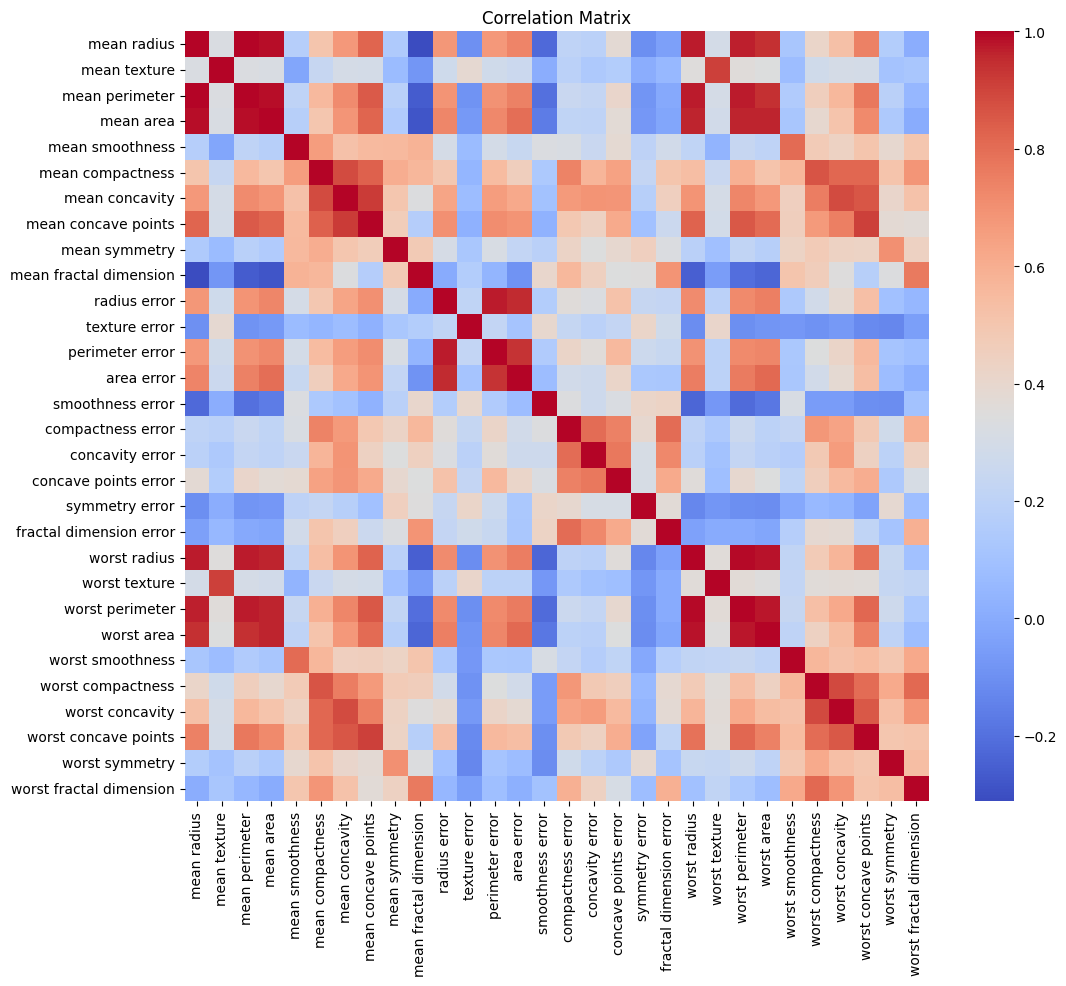

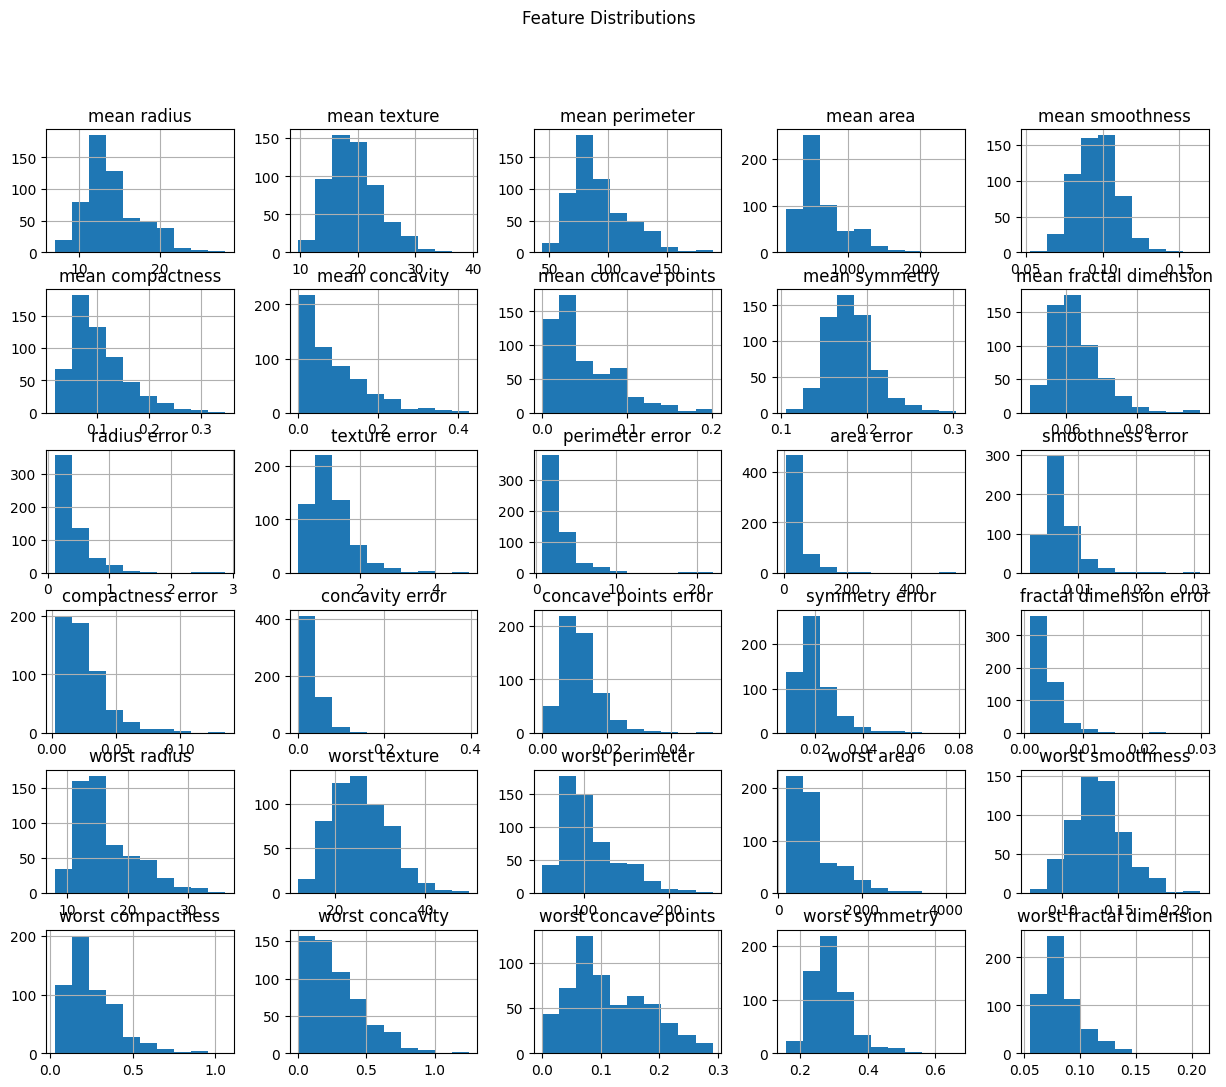

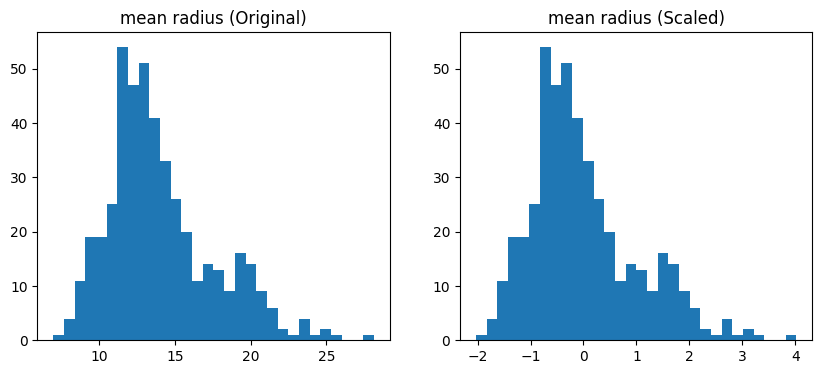

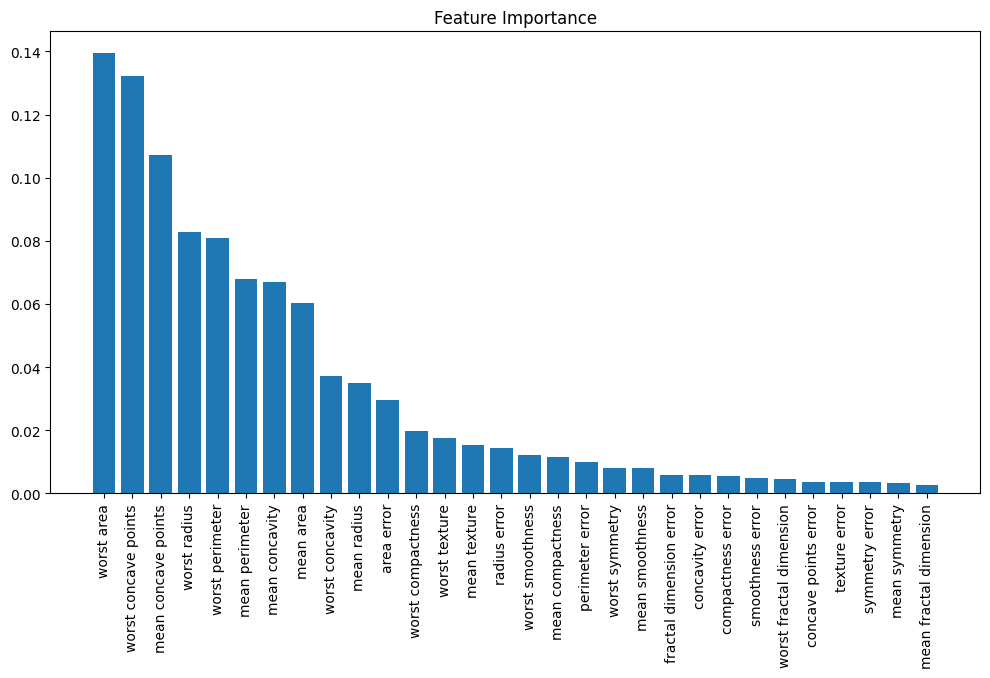

In [17]:
dataset = Dataset()

# Split data
X_train, X_test, y_train, y_test = dataset.split_data()

# Scale data
X_train_scaled, X_test_scaled = dataset.scale_data(X_train, X_test, 'standard')

# Visualizations
dataset.plot_class_distribution()
dataset.plot_correlation_matrix()
dataset.plot_feature_distributions()

# Scaling comparison
dataset.plot_feature_before_after_scaling(X_train, X_train_scaled, 'mean radius')

# Feature importance
dataset.feature_importance()